In [3]:
import pandas as pd

df = pd.read_csv("student_performance_prediction.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Shape: (40000, 7)

Columns:
['Student ID', 'Study Hours per Week', 'Attendance Rate', 'Previous Grades', 'Participation in Extracurricular Activities', 'Parent Education Level', 'Passed']

First 5 rows:
  Student ID  Study Hours per Week  Attendance Rate  Previous Grades  \
0     S00001                  12.5              NaN             75.0   
1     S00002                   9.3             95.3             60.6   
2     S00003                  13.2              NaN             64.0   
3     S00004                  17.6             76.8             62.4   
4     S00005                   8.8             89.3             72.7   

  Participation in Extracurricular Activities Parent Education Level Passed  
0                                         Yes                 Master    Yes  
1                                          No            High School     No  
2                                          No              Associate     No  
3                                         Yes       

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
df = pd.read_csv("student_performance_prediction.csv")

print(df.head())
print(df.shape)

  Student ID  Study Hours per Week  Attendance Rate  Previous Grades  \
0     S00001                  12.5              NaN             75.0   
1     S00002                   9.3             95.3             60.6   
2     S00003                  13.2              NaN             64.0   
3     S00004                  17.6             76.8             62.4   
4     S00005                   8.8             89.3             72.7   

  Participation in Extracurricular Activities Parent Education Level Passed  
0                                         Yes                 Master    Yes  
1                                          No            High School     No  
2                                          No              Associate     No  
3                                         Yes               Bachelor     No  
4                                          No                 Master     No  
(40000, 7)


In [6]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  object 
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  object 
 5   Parent Education Level                       38000 non-null  object 
 6   Passed                                       38000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.1+ MB
None

Missing Values:
Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1

In [7]:
df.drop("Student ID", axis=1, inplace=True)

In [8]:
num_cols = [
    "Study Hours per Week",
    "Attendance Rate",
    "Previous Grades"
]

imputer = SimpleImputer(strategy='mean')

df[num_cols] = imputer.fit_transform(df[num_cols])

In [9]:
le = LabelEncoder()

df["Participation in Extracurricular Activities"] = le.fit_transform(
    df["Participation in Extracurricular Activities"]
)

df["Parent Education Level"] = le.fit_transform(
    df["Parent Education Level"]
)

df["Passed"] = le.fit_transform(
    df["Passed"]
)

print(df.head())

   Study Hours per Week  Attendance Rate  Previous Grades  \
0                  12.5        75.276323             75.0   
1                   9.3        95.300000             60.6   
2                  13.2        75.276323             64.0   
3                  17.6        76.800000             62.4   
4                   8.8        89.300000             72.7   

   Participation in Extracurricular Activities  Parent Education Level  Passed  
0                                            1                       4       1  
1                                            0                       3       0  
2                                            0                       0       0  
3                                            1                       1       0  
4                                            0                       4       0  


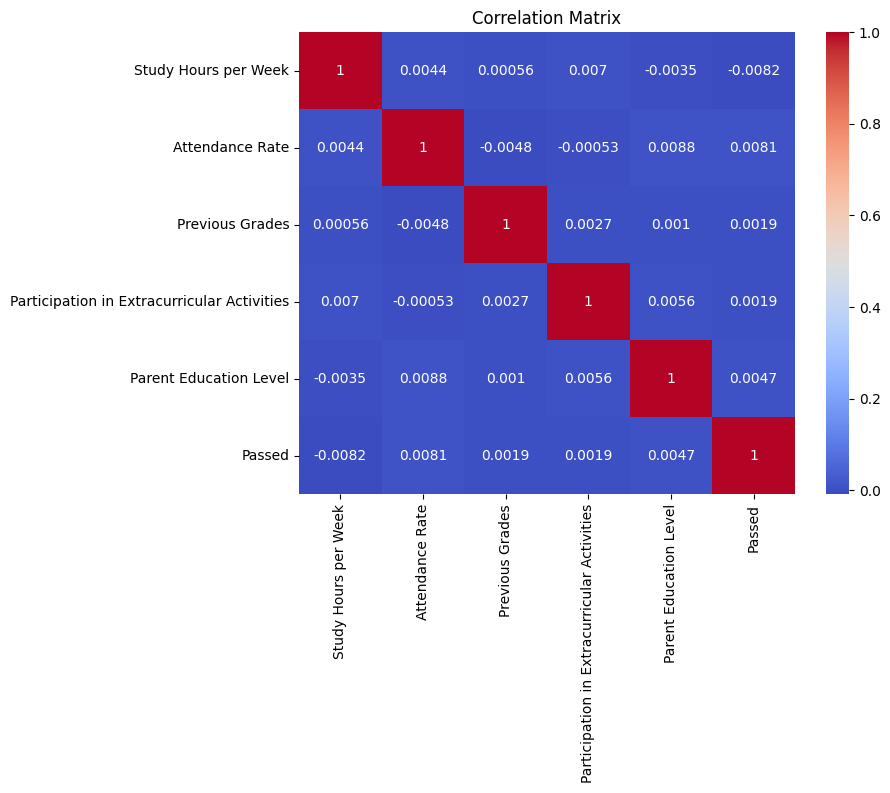

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

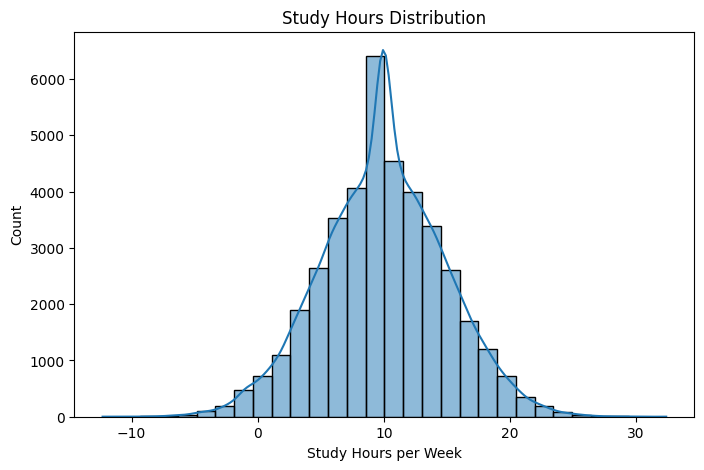

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Study Hours per Week"],
    bins=30,
    kde=True
)

plt.title("Study Hours Distribution")
plt.show()

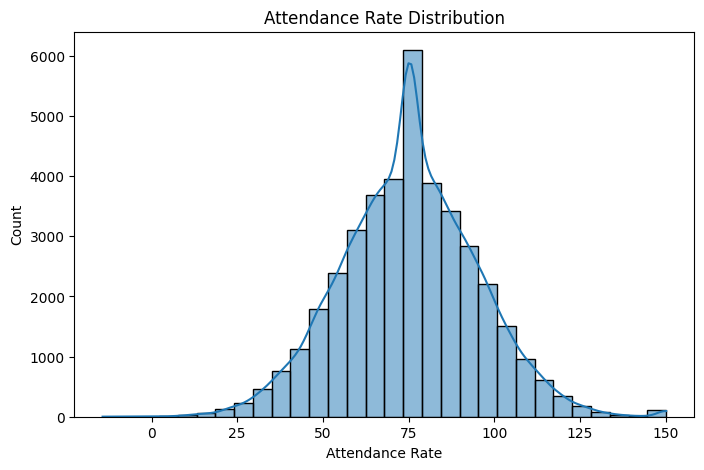

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Attendance Rate"],
    bins=30,
    kde=True
)

plt.title("Attendance Rate Distribution")
plt.show()

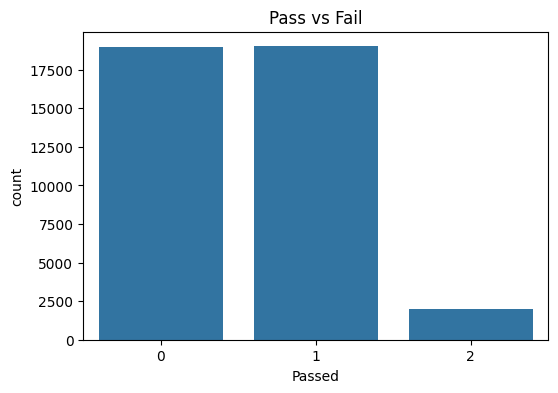

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Passed",
    data=df
)

plt.title("Pass vs Fail")
plt.show()

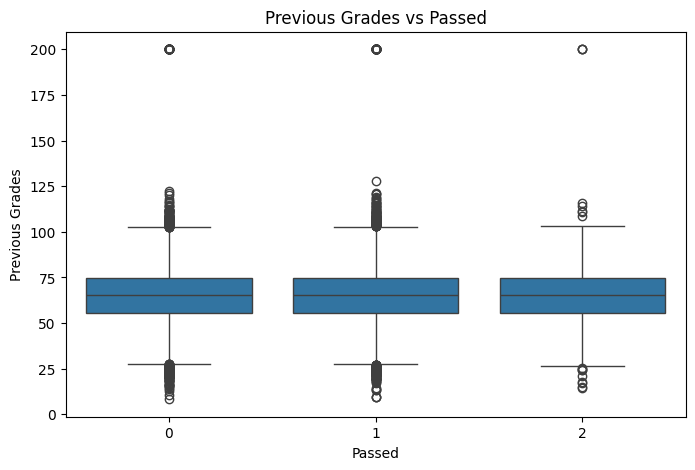

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Passed",
    y="Previous Grades",
    data=df
)

plt.title("Previous Grades vs Passed")
plt.show()

In [15]:
X = df.drop("Passed", axis=1)

y = df["Passed"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.476625


In [18]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.450625


In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.46725


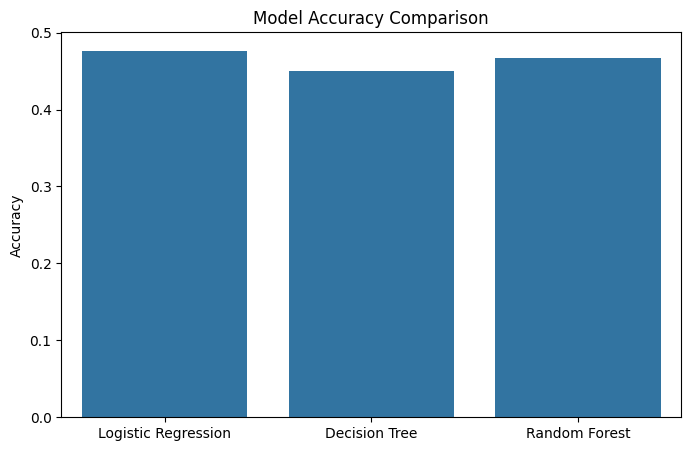

In [20]:
models = ["Logistic Regression",
          "Decision Tree",
          "Random Forest"]

scores = [lr_acc,
          dt_acc,
          rf_acc]

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=scores
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [21]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.47      0.51      0.49      3794
           1       0.47      0.47      0.47      3788
           2       0.13      0.00      0.01       418

    accuracy                           0.47      8000
   macro avg       0.36      0.33      0.32      8000
weighted avg       0.45      0.47      0.46      8000



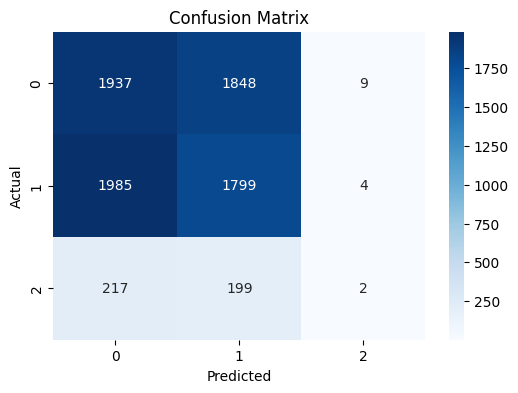

In [22]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                                       Feature  Importance
2                              Previous Grades    0.316886
1                              Attendance Rate    0.313603
0                         Study Hours per Week    0.271561
4                       Parent Education Level    0.063429
3  Participation in Extracurricular Activities    0.034521


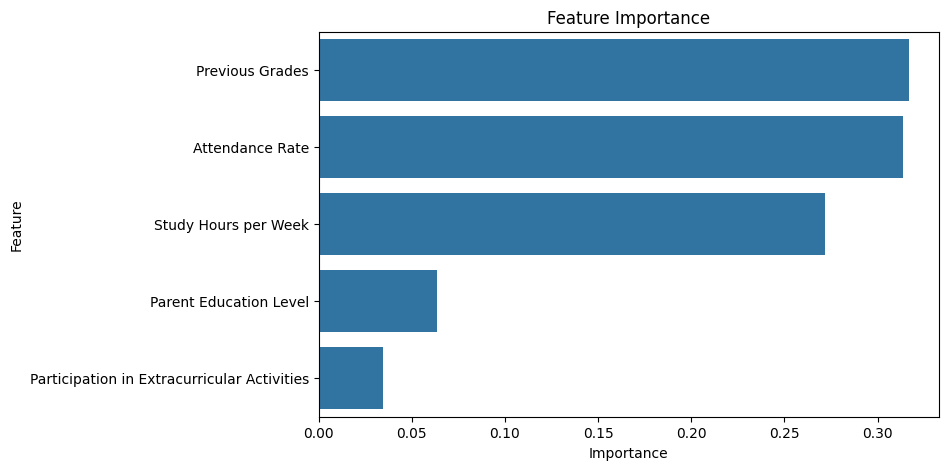

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [25]:
new_student = pd.DataFrame({

    "Study Hours per Week":[15],

    "Attendance Rate":[90],

    "Previous Grades":[85],

    "Participation in Extracurricular Activities":[1],

    "Parent Education Level":[2]

})

prediction = rf.predict(new_student)

if prediction[0] == 1:
    print("PASS")
else:
    print("FAIL")

FAIL
